# Test

In [11]:
import yfinance as yf

In [12]:
ticker = "BTC-EUR"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31", interval="1wk", timeout=10)
pricesBTC = data['Close'].dropna()

[*********************100%***********************]  1 of 1 completed


In [13]:
print(pricesBTC)

Ticker           BTC-EUR
Date                    
2020-01-01   7320.774902
2020-01-08   7933.511719
2020-01-15   7889.409180
2020-01-22   8490.750000
2020-01-29   8311.948242
...                  ...
2025-11-26  78557.890625
2025-12-03  79714.218750
2025-12-10  74765.687500
2025-12-17  74112.296875
2025-12-24  75287.914062

[313 rows x 1 columns]


In [14]:
ticker = "ETH-EUR"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31", interval="1wk", timeout=10)
pricesETH = data['Close'].dropna()
print(pricesETH)

[*********************100%***********************]  1 of 1 completed

Ticker          ETH-EUR
Date                   
2020-01-01   128.722794
2020-01-08   149.144073
2020-01-15   153.078720
2020-01-22   160.015152
2020-01-29   171.337280
...                 ...
2025-11-26  2578.120117
2025-12-03  2856.135742
2025-12-10  2522.870850
2025-12-17  2512.440430
2025-12-24  2529.813721

[313 rows x 1 columns]


In [15]:
ticker = "aapl"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31", interval="1wk", timeout=10)
pricesAAPL = data['Close'].dropna()
print(pricesAAPL)

[*********************100%***********************]  1 of 1 completed

Ticker            AAPL
Date                  
2020-01-01   71.861832
2020-01-08   75.303329
2020-01-15   76.240181
2020-01-22   76.509903
2020-01-29   76.789276
...                ...
2025-11-26  285.659271
2025-12-03  276.665985
2025-12-10  274.100739
2025-12-17  271.854919
2025-12-24  272.573547

[313 rows x 1 columns]


In [16]:
ticker = "^GSPC"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31", interval="1wk", timeout=10)
pricesSP = data['Close'].dropna()
print(pricesSP)

[*********************100%***********************]  1 of 1 completed

Ticker            ^GSPC
Date                   
2020-01-01  3237.179932
2020-01-08  3283.149902
2020-01-15  3320.790039
2020-01-22  3276.239990
2020-01-29  3297.590088
...                 ...
2025-11-26  6829.370117
2025-12-03  6840.509766
2025-12-10  6800.259766
2025-12-17  6909.790039
2025-12-24  6896.240234

[313 rows x 1 columns]


In [17]:
ticker = "SNDL"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31", interval="1wk", timeout=10)
pricesSNDL = data['Close'].dropna()
print(pricesSNDL)

[*********************100%***********************]  1 of 1 completed

Ticker           SNDL
Date                 
2020-01-01  28.400000
2020-01-08  28.700001
2020-01-15  33.500000
2020-01-22  26.400000
2020-01-29  14.500000
...               ...
2025-11-26   1.700000
2025-12-03   1.710000
2025-12-10   2.150000
2025-12-17   1.780000
2025-12-24   1.650000

[313 rows x 1 columns]


In [18]:
ticker = "DOGE-EUR"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31", interval="1wk", timeout=10)
pricesDOGE = data['Close'].dropna()
print(pricesDOGE)

[*********************100%***********************]  1 of 1 completed

Ticker      DOGE-EUR
Date                
2020-01-01  0.002182
2020-01-08  0.002220
2020-01-15  0.002144
2020-01-22  0.002222
2020-01-29  0.002266
...              ...
2025-11-26  0.125531
2025-12-03  0.127311
2025-12-10  0.112126
2025-12-17  0.109536
2025-12-24  0.104955

[313 rows x 1 columns]


In [19]:
ticker = "EURUSD=X"
data = yf.download(ticker, start="2020-01-01", end="2025-12-31", interval="1wk", timeout=10)
pricesEURUSD = data['Close'].dropna()
print(pricesEURUSD)

[*********************100%***********************]  1 of 1 completed

Ticker      EURUSD=X
Date                
2020-01-01  1.119799
2020-01-08  1.113573
2020-01-15  1.109693
2020-01-22  1.101977
2020-01-29  1.106293
...              ...
2025-11-26  1.160766
2025-12-03  1.164144
2025-12-10  1.175461
2025-12-17  1.176595
2025-12-24  1.177288

[313 rows x 1 columns]


In [20]:
import os  # <--- À AJOUTER en haut de votre fichier
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def simulation_dca_ia(prices, montant_DCA, ticker_name="Actif"):
    
    parts_classique, parts_ia, reserve_cash = 0, 0, 0
    history = []

    for i in range(len(prices) - 1):
        prix_actuel = float(prices.iloc[i])
        prix_futur = float(prices.iloc[i+1])
        
        # DCA Classique
        parts_classique += montant_DCA / prix_actuel
        
        # DCA IA (Logique de report total)
        invest_ce_mois = montant_DCA + reserve_cash
        if prix_futur < prix_actuel:
            mont_a_placer = 0
            reserve_cash = invest_ce_mois
        else:
            mont_a_placer = invest_ce_mois
            reserve_cash = 0
            
        parts_ia += mont_a_placer / prix_actuel
        
        history.append({
            'Date': prices.index[i],
            'Val_Classique': parts_classique * prix_actuel,
            'Val_IA': (parts_ia * prix_actuel) + reserve_cash,
            'Qty_Classique': parts_classique,
            'Qty_IA': parts_ia
        })

    df = pd.DataFrame(history).set_index('Date')
    
    # Calculs finaux
    final_val_c = df['Val_Classique'].iloc[-1]
    final_val_ia = df['Val_IA'].iloc[-1]
    diff_pct = ((final_val_ia - final_val_c) / final_val_c) * 100

    # --- Figure 1 : Valeur du Portefeuille ---
    fig, ax = plt.subplots(figsize=(10, 5), facecolor='#F8FAFC')
    ax.plot(df['Val_Classique'], label='DCA Classique', color='#94A3B8', linestyle='--')
    ax.plot(df['Val_IA'], label='DCA IA Boosté', color='#3B82F6', linewidth=2)
    ax.fill_between(df.index, df['Val_Classique'], df['Val_IA'], color='#3B82F6', alpha=0.1)
    
    ax.text(0.02, 0.95, f"Surperformance : +{diff_pct:.1f}%", 
            transform=ax.transAxes, weight='bold', fontsize=12, color='#1E40AF',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#3B82F6', boxstyle='round,pad=0.5'))

    ax.set_title(f"Valeur du Portefeuille : {ticker_name} (M={montant_DCA}€)", fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.2)
    
    # --- Figure 2 : Quantité de Tokens ---
    fig2, ax2 = plt.subplots(figsize=(10, 5), facecolor='#F8FAFC')
    ax2.plot(df['Qty_Classique'], label='Parts DCA Classique', color='#64748B', linestyle=':')
    ax2.plot(df['Qty_IA'], label='Parts IA Boosté', color='#10B981', linewidth=2)
    
    ax2.text(0.02, 0.95, f"Tokens en plus : +{diff_pct:.1f}%", 
            transform=ax2.transAxes, weight='bold', fontsize=12, color='#065F46',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#10B981', boxstyle='round,pad=0.5'))

    ax2.set_title(f"Accumulation d'actifs : {ticker_name}", fontweight='bold')
    ax2.legend(loc='lower right')
    ax2.grid(axis='y', alpha=0.2)
    
    # ==========================================
    # BLOC AJOUTÉ : SAUVEGARDE DES GRAPHIQUES
    # ==========================================
    output_dir = "graphiques" # Nom du sous-dossier
    if not os.path.exists(output_dir):
        os.makedirs(output_dir) # Crée le dossier s'il n'existe pas encore
    
    # Sauvegarde des fichiers avec des noms dynamiques basés sur le ticker
    fig.savefig(f"{output_dir}/valeur_{ticker_name}.png", dpi=300, bbox_inches='tight')
    fig2.savefig(f"{output_dir}/quantite_{ticker_name}.png", dpi=300, bbox_inches='tight')
    # ==========================================
    
    return fig, fig2, round(final_val_c, 2), round(final_val_ia, 2), round(diff_pct, 1)

C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_actuel = float(prices.iloc[i])
C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_futur = float(prices.iloc[i+1])


(<Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>,
 np.float64(95674.11),
 np.float64(101422.1),
 np.float64(6.0))

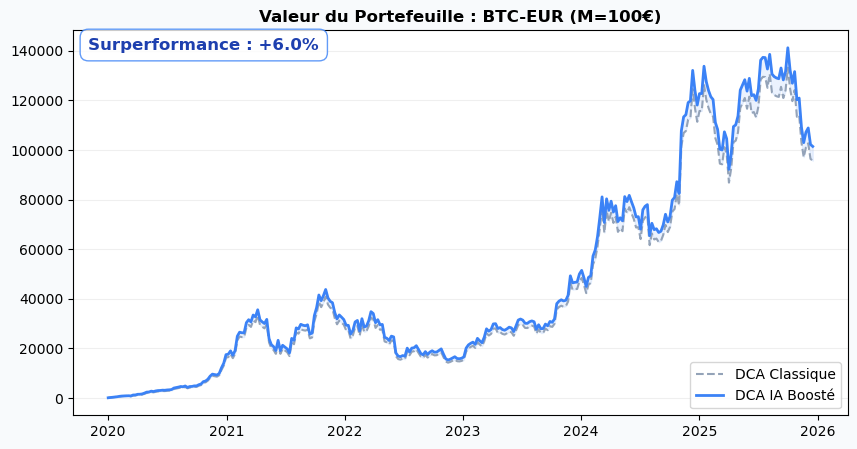

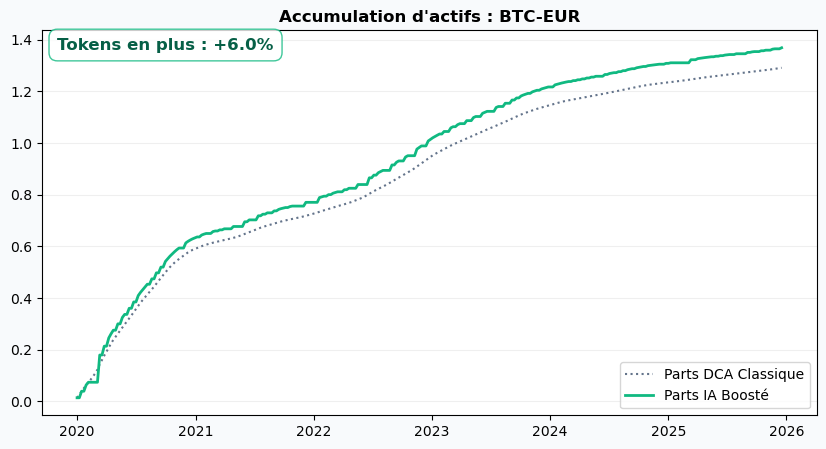

In [21]:
simulation_dca_ia(pricesBTC, 100, "BTC-EUR")

C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_actuel = float(prices.iloc[i])
C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_futur = float(prices.iloc[i+1])


(<Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>,
 np.float64(956741.08),
 np.float64(1014221.02),
 np.float64(6.0))

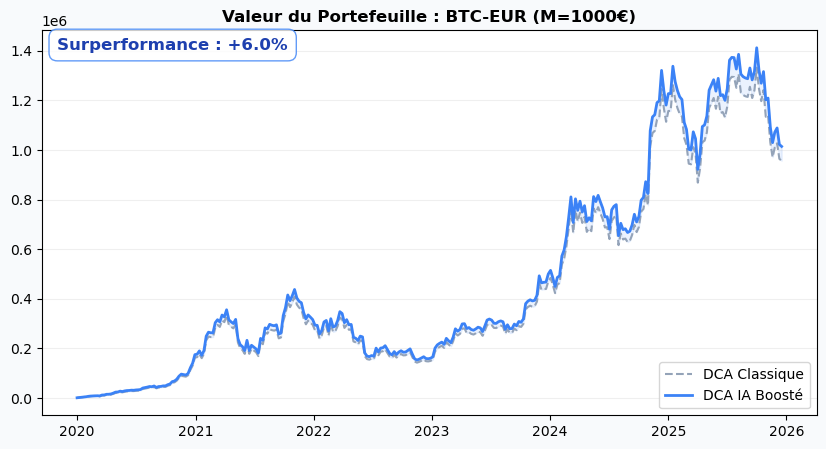

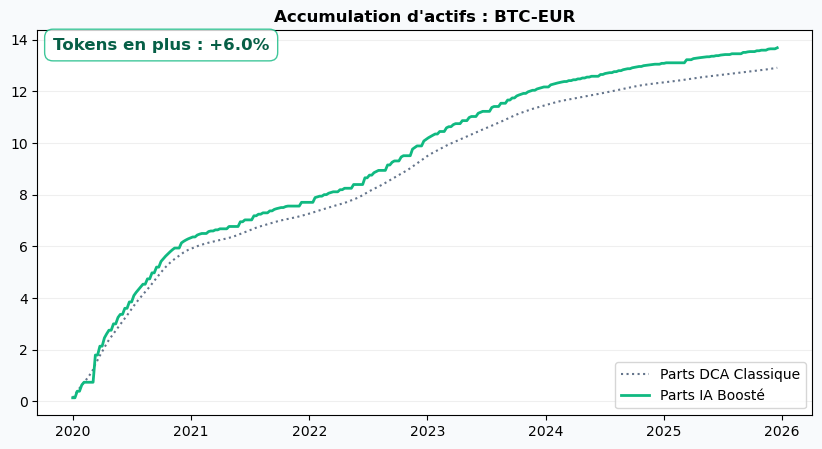

In [22]:
simulation_dca_ia(pricesBTC, 1000, "BTC-EUR")

## Conclusion

Changer le montant_DCA ne modifie pas la surperformance

---

C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_actuel = float(prices.iloc[i])
C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_futur = float(prices.iloc[i+1])


(<Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>,
 np.float64(90562.66),
 np.float64(98865.01),
 np.float64(9.2))

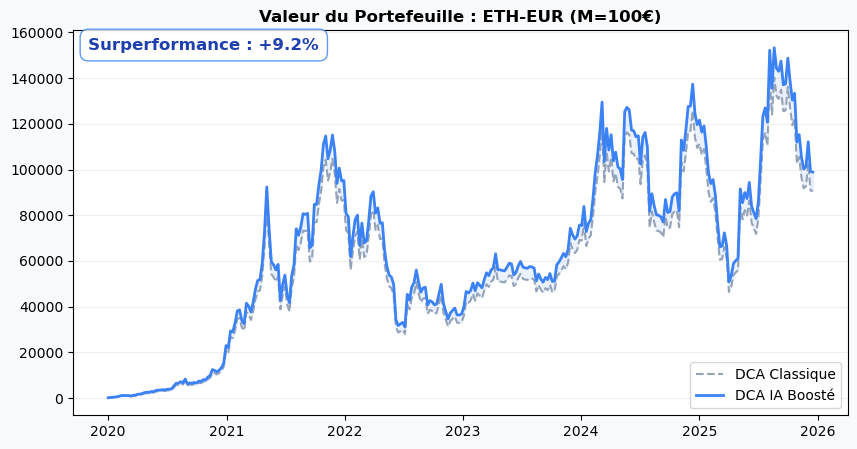

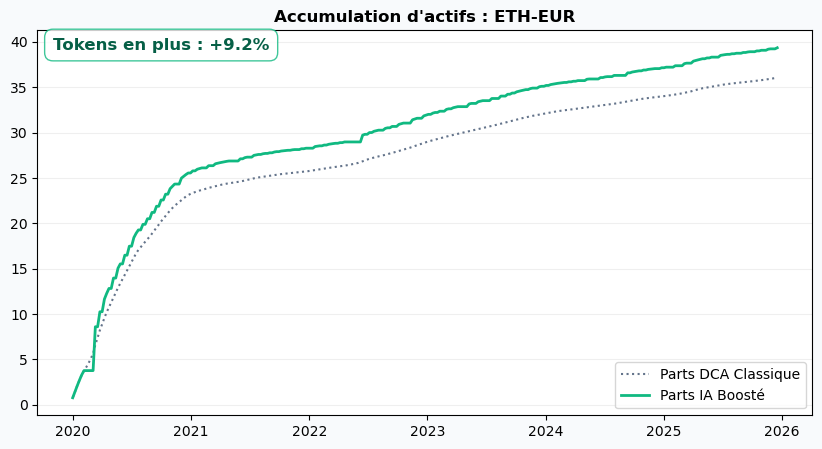

In [23]:
simulation_dca_ia(pricesETH, 100,"ETH-EUR")

C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_actuel = float(prices.iloc[i])
C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_futur = float(prices.iloc[i+1])


(<Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>,
 np.float64(905626.55),
 np.float64(988650.06),
 np.float64(9.2))

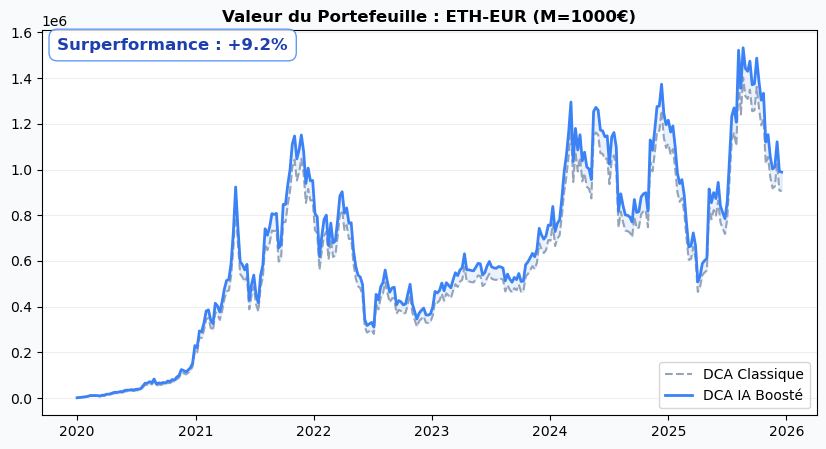

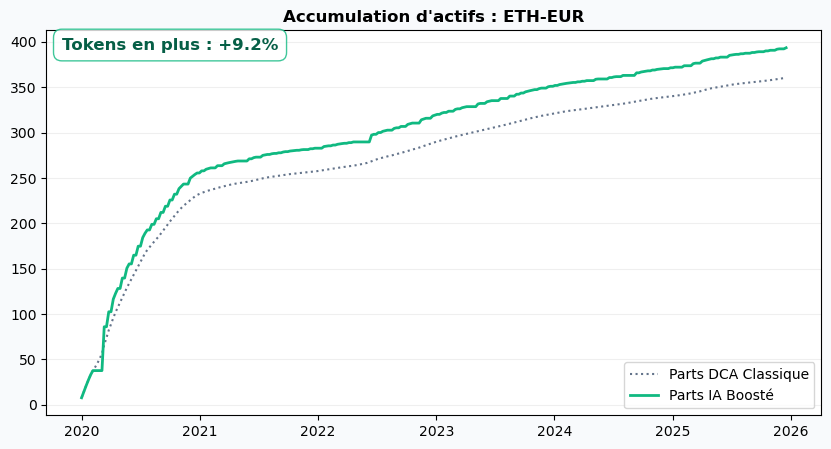

In [24]:
simulation_dca_ia(pricesETH, 1000,"ETH-EUR")

## Conclusion

Même chose pour le montant_DCA (logique).
On note aussi qu'avec un prix d'actif moins élevé (prix ETH < prix BTC), la surperformance est supérieure (voir papier).

C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_actuel = float(prices.iloc[i])
C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_futur = float(prices.iloc[i+1])


(<Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>,
 np.float64(57509.26),
 np.float64(58889.13),
 np.float64(2.4))

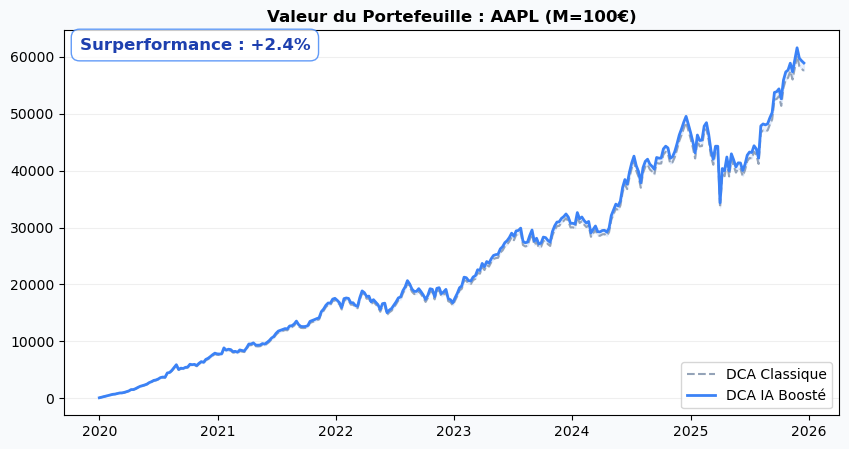

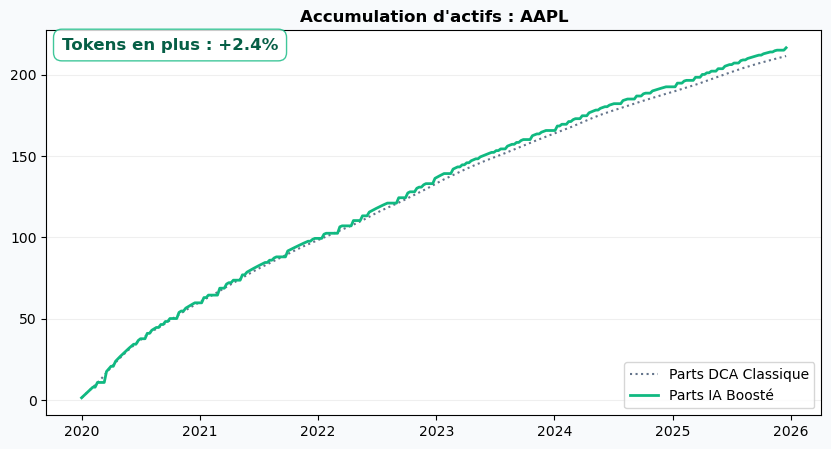

In [25]:
simulation_dca_ia(pricesAAPL, 100, "AAPL")

C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_actuel = float(prices.iloc[i])
C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_futur = float(prices.iloc[i+1])


(<Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>,
 np.float64(278862.29),
 np.float64(303750.63),
 np.float64(8.9))

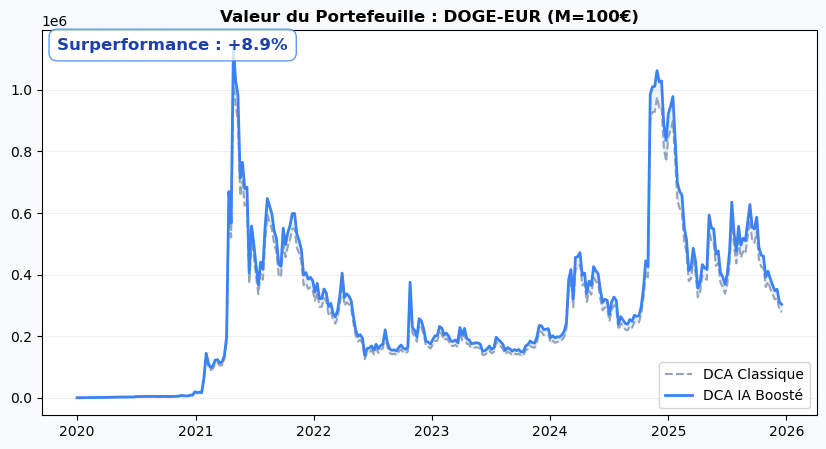

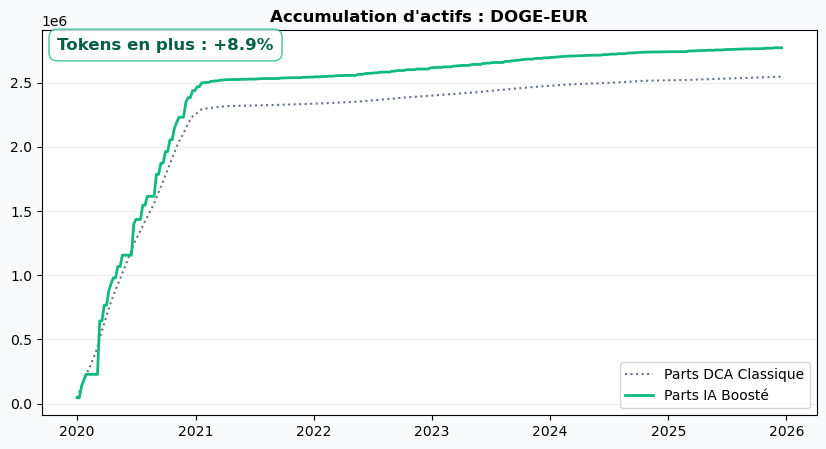

In [26]:
simulation_dca_ia(pricesDOGE, 100, "DOGE-EUR")

C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_actuel = float(prices.iloc[i])
C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_futur = float(prices.iloc[i+1])


(<Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>,
 np.float64(22055.38),
 np.float64(24361.03),
 np.float64(10.5))

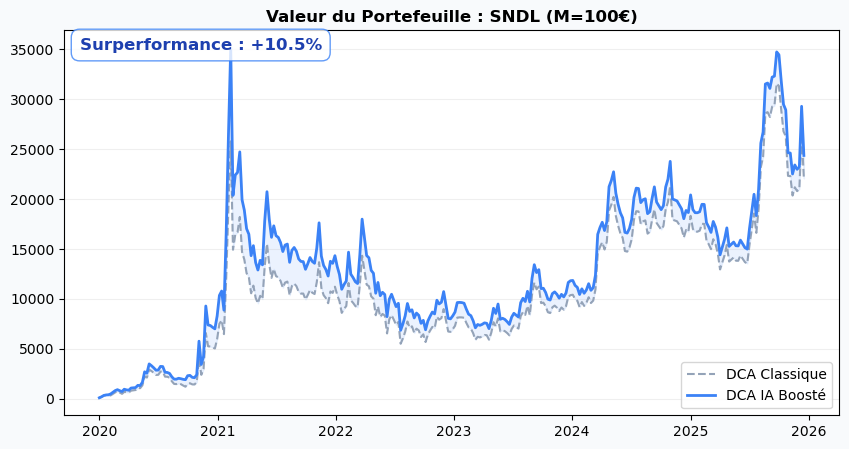

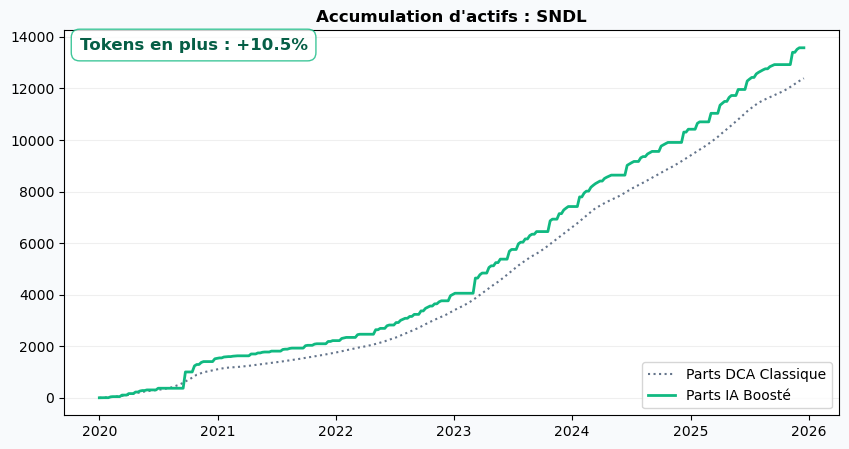

In [27]:
simulation_dca_ia(pricesSNDL, 100, "SNDL")

## Conclusion

La surperformance n'est pas inversement prop au prix de l'actif car on fait mieux avec le SNDL qui a un prix plus haut que le DOGE coin (la diff est sûrement la volatilité ici).

C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_actuel = float(prices.iloc[i])
C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_futur = float(prices.iloc[i+1])


(<Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>,
 np.float64(49426.37),
 np.float64(50164.18),
 np.float64(1.5))

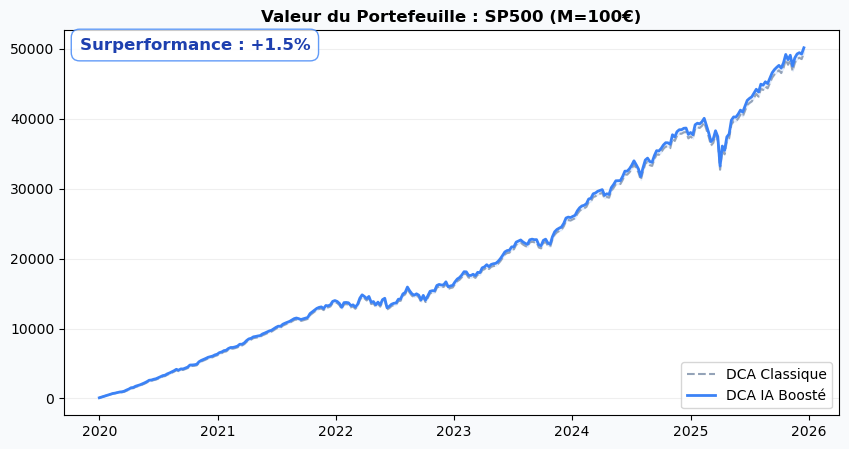

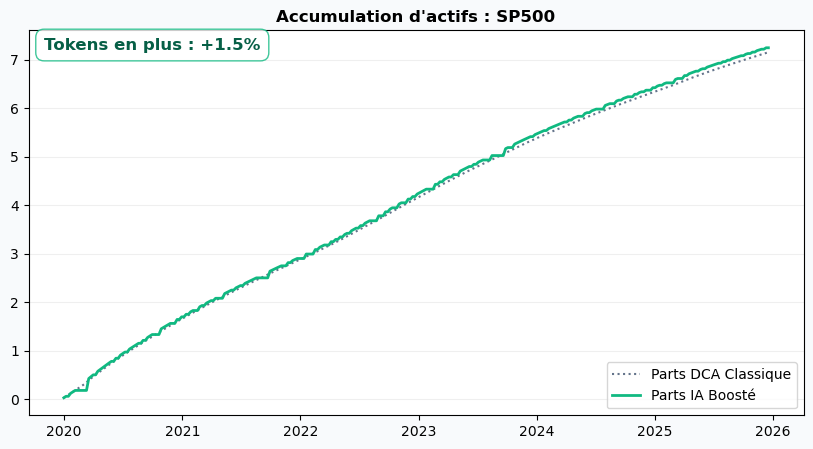

In [28]:
simulation_dca_ia(pricesSP, 100, "SP500")

C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_actuel = float(prices.iloc[i])
C:\Users\aleor\AppData\Local\Temp\ipykernel_14700\3641360078.py:13: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prix_futur = float(prices.iloc[i+1])


(<Figure size 1000x500 with 1 Axes>,
 <Figure size 1000x500 with 1 Axes>,
 np.float64(33096.44),
 np.float64(33355.41),
 np.float64(0.8))

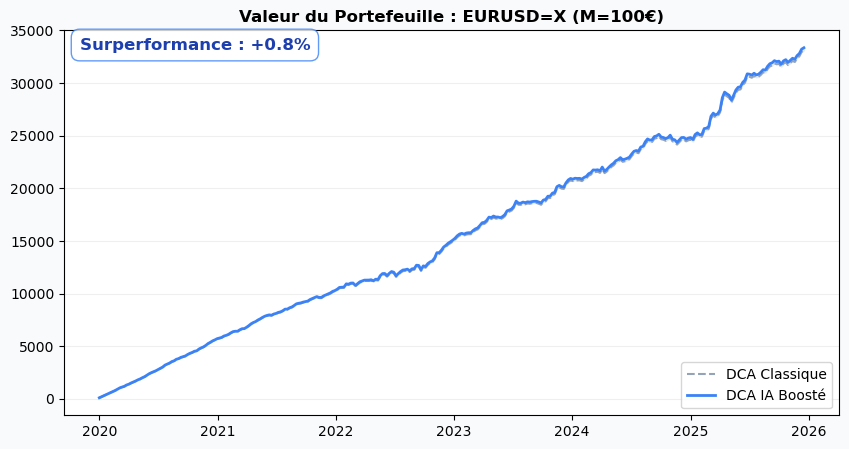

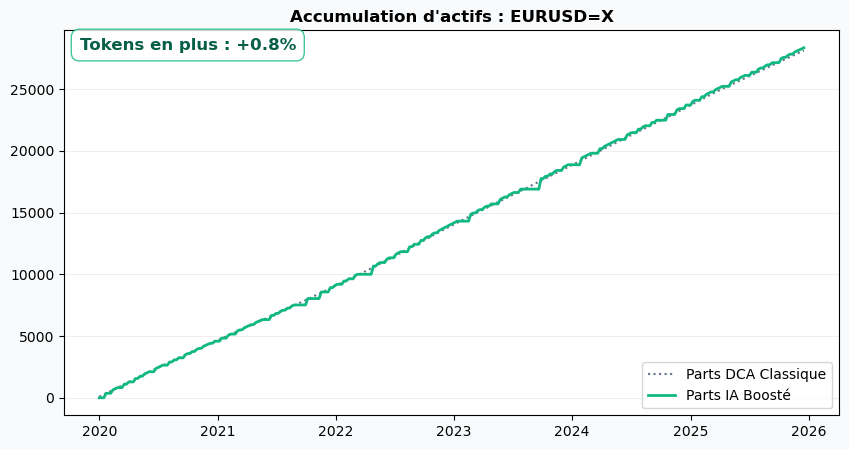

In [29]:
simulation_dca_ia(pricesEURUSD, 100, "EURUSD=X")